In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

In [18]:
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(parent_dir)
interpolated_dir = os.path.join(parent_dir, "dataset_interpolated_fixed")
# features = ["game_completed", "relative_strength", "score_difference", "type.id", "home_has_possession", "end.down", "end.yardsToEndzone", "end.distance", "field_position_shift", "home_timeouts_left", "away_timeouts_left"]
# features = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.downNeg", "end.distanceNeg", "end.yardsToEndzoneNeg", "home_timeouts_left", "away_timeouts_left", "predicted_drive_points_ev"]
# features = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.downNeg", "end.distanceNeg", "end.yardsToEndzoneNeg", "home_timeouts_left", "away_timeouts_left"]
features = ["relative_strength", "score_difference", "ezS"]

/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML


In [19]:
# Reset the modules
modules_to_reload = [
    'process_data',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

import process_data
training_data = process_data.load_data(interpolated_dir, 
                                       years = [2016, 2017,2018, 2019, 2020, 2021, 2022, 2023], 
                                       history_length = 0, 
                                       features = features, 
                                       label_feature = "home_win")

# validation_data = process_data.load_data(interpolated_dir, 
#                                        years = [2023], 
#                                        history_length = 0, 
#                                        features = features, 
#                                        label_feature = "home_win",
#                                        train = True
#                                        )

test_data = process_data.load_data(interpolated_dir, 
                                       years = [2024, 2025],
                                       history_length = 0, 
                                       features = features, 
                                       label_feature = "home_win",
                                       train = False
                                       )

Loading data for 2022
  Processing 271 CSV files in parallel with 8 workers...
  Completed processing 2022
Loading data for 2025
skipping  2025
Loading data for 2024
skipping  2024
Loading data for 2023
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2023
Loading data for .DS_Store
Loading data for 2017
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2017
Loading data for 2019
  Processing 256 CSV files in parallel with 8 workers...
  Completed processing 2019
Loading data for 2021
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2021
Loading data for 2020
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2020
Loading data for 2018
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2018
Loading data for 2016
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2016
Loading data for 2022
skipping  2022
Loadin

In [5]:
yards_idx = features.index("end.distanceNeg")
poss_idx = features.index("home_has_possession")

print(f"{'home_has_possession':>22} {'end.distanceNeg':>20}")
print("-" * 45)
count = 0
for entries in training_data.values():
    for entry in entries:
        row = entry["rows"]
        print(f"{row[poss_idx]:>22.0f} {row[yards_idx]:>20.1f}")
        count += 1
        if count >= 10:
            break
    if count >= 10:
        break

print(f"{'home_has_possession':>22} {'end.distanceNeg':>20}")
print("-" * 45)
count = 0
for entries in test_data.values():
    for entry in entries:
        row = entry["rows"]
        print(f"{row[poss_idx]:>22.0f} {row[yards_idx]:>20.1f}")
        count += 1
        if count >= 10:
            break
    if count >= 10:
        break


   home_has_possession      end.distanceNeg
---------------------------------------------
                     0                -10.0
                     0                -10.0
                     1                  7.0
                     1                  7.0
                     0                 -7.0
                     0                 -7.0
                     0                 -7.0
                     1                 10.0
                     0                -10.0
                     0                -10.0
   home_has_possession      end.distanceNeg
---------------------------------------------
                     0                 -4.0
                     0                -10.0
                     1                  5.0
                     1                  6.0
                     0                -10.0
                     0                 -6.0
                     1                 10.0
                     1                  6.0
                     1      

In [20]:
other_features = [
            "home_has_possession", # Binary indicator
            "end.downNeg",            # Down number (1-4, discrete)
            "home_timeouts_left",  # Discrete count (0-3)
            "away_timeouts_left",  # Discrete count (0-3)
            "score_difference",
        ]
numeric_features = [
    "game_completed",
    "relative_strength", 
    # "end.yardsToEndzoneNeg", 
    "ezS",
    "end.distanceNeg",
    "predicted_drive_points_ev"
]

In [21]:
# Setup model for each timestep
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
# create an array of logistic regression models

modules_to_reload = [
    'models.logistic_regression',
    'models.Model'
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]
from models.Model import Model
from models.logistic_regression import setup_logistic_regression_models

models = setup_logistic_regression_models(training_data, None, numeric_features, other_features, features, optimize_hyperparams=False, use_calibration=False)


Processing timestep: 0.0
Timestep 0.00% : Training Loss = 0.6252, Accuracy = 0.6454, Test Loss = 0.6362, Test Accuracy = 0.6378
Processing timestep: 0.005
Timestep 0.50% : Training Loss = 0.6331, Accuracy = 0.6301, Test Loss = 0.6384, Test Accuracy = 0.6000
Processing timestep: 0.01
Timestep 1.00% : Training Loss = 0.6211, Accuracy = 0.6423, Test Loss = 0.6300, Test Accuracy = 0.6354
Processing timestep: 0.015
Timestep 1.50% : Training Loss = 0.6350, Accuracy = 0.6341, Test Loss = 0.6211, Test Accuracy = 0.6497
Processing timestep: 0.02
Timestep 2.00% : Training Loss = 0.6343, Accuracy = 0.6376, Test Loss = 0.6467, Test Accuracy = 0.6098
Processing timestep: 0.025
Timestep 2.50% : Training Loss = 0.6320, Accuracy = 0.6360, Test Loss = 0.6363, Test Accuracy = 0.6537
Processing timestep: 0.03
Timestep 3.00% : Training Loss = 0.6207, Accuracy = 0.6591, Test Loss = 0.6307, Test Accuracy = 0.6422
Processing timestep: 0.035
Timestep 3.50% : Training Loss = 0.6273, Accuracy = 0.6442, Test Los

In [26]:
features = ["game_completed", "relative_strength", "score_difference", "home_has_possession", "end.down", "end.distance", "end.yardsToEndzone", "home_timeouts_left", "away_timeouts_left", "predicted_drive_points_ev"]

def is_close_to_scoring(row, home_has_possession, score_difference):
    yards_to_endzone = row[features.index("end.yardsToEndzone")]
    down = row[features.index("end.down")]

    # score_difference = home_score - away_score
    # if score_difference > 0: home is winning, away is trailing
    # if score_difference < 0: home is trailing
    if score_difference > 0:
        trailing_has_ball = (home_has_possession == 0)
    else:
        trailing_has_ball = (home_has_possession == 1)

    if not trailing_has_ball:
        return False

    # Trailing team has the ball - check field position
    in_td_range = yards_to_endzone <= 25
    in_fg_range = yards_to_endzone <= 40 and down >= 3
    return in_td_range or in_fg_range


def find_edge_cases(test_data, features, timestep_threshold=0.97, max_score_diff=7):
    """
    Extract edge cases from the test dataset.
    An edge case is an endgame play where:
      1. game_completed >= timestep_threshold (endgame)
      2. |score_difference| < max_score_diff (close game, strictly less than 7)
      3. The trailing team is close to scoring (heuristic based on field position)
    Returns a list of (feature_row, label, homeWinProbability) tuples.
    """
    edge_cases = []
    total = 0
    for timestep_key, entries in test_data.items():
        for entry in entries:
            total += 1
            row = entry["rows"]
            label = entry["label"]
            hwp = entry.get("homeWinProbability", None)

            game_completed = row[features.index("game_completed")]
            score_diff = row[features.index("score_difference")]
            home_poss = row[features.index("home_has_possession")]

            # Condition 1: endgame
            if game_completed < timestep_threshold:
                continue

            # Condition 2: close game (strictly less than 7 points difference)
            if abs(score_diff) >= max_score_diff:
                continue

            # Condition 3: trailing team is close to scoring
            if score_diff == 0:
                # Tied game: whoever has ball in scoring position is an edge case
                yards_to_endzone = row[features.index("end.yardsToEndzone")]
                down = row[features.index("end.down")]
                if not (yards_to_endzone <= 25 or (yards_to_endzone <= 40 and down >= 3)):
                    continue
            else:
                if not is_close_to_scoring(row, home_poss, score_diff):
                    continue

            edge_cases.append((row, label, hwp))

    return edge_cases, total


def predict_edge_cases(edge_cases, models, features):
    """
    Run inference on extracted edge cases.
    edge_cases: list of (feature_row, label, homeWinProbability)
    Prints P(home win), ESPN homeWinProbability, and ground truth label.
    """
    model_keys = sorted(models.keys())
    brier_sum = 0.0
    espn_brier_sum = 0.0
    n_features = len(features)

    for row, label, hwp in edge_cases:
        timestep = row[features.index("game_completed")]

        key = max((k for k in model_keys if k <= timestep), default=model_keys[0])
        model = models[key]

        # Use only the model features (first n_features values), exclude homeWinProbability
        feature_input = row[:n_features].reshape(1, -1)
        prob = model.predict_proba(feature_input)[0][1]
        brier_sum += (prob - label) ** 2

        hwp_str = f"{hwp:.4f}" if hwp is not None else "N/A"
        if hwp is not None:
            espn_brier_sum += (hwp - label) ** 2
        print(
            f"score_diff={row[features.index('score_difference')]:+.0f}  "
            f"home_poss={int(row[features.index('home_has_possession')])}  "
            f"yards_to_ez={row[features.index('end.yardsToEndzone')]:.1f}  "
            f"down={int(row[features.index('end.down')])}  "
            f"game_completed={row[features.index('game_completed')]:.3f}  "
            f"| P(Home win)={prob:.4f}  "
            f"ESPN={hwp_str}  "
            f"GT={label:.0f}"
        )

    brier_score = brier_sum / len(edge_cases) if edge_cases else float("nan")
    print(f"\n{'='*70}")
    print(f"Total edge cases found: {len(edge_cases)}")
    print(f"Brier Score (vs GT):    {brier_score:.4f}")
    print(f"ESPN Brier Score (vs GT): {espn_brier_sum / len(edge_cases) if edge_cases else float('nan'):.4f}")

# Find edge cases in the test dataset and run inference
edge_cases_from_test, total_edge_cases = find_edge_cases(test_data, features, timestep_threshold=0.97, max_score_diff=7)
print(f"Found {len(edge_cases_from_test)} edge cases in test data.")
print(f"Total test cases: {total_edge_cases}")
predict_edge_cases(edge_cases_from_test, models, features)


Found 1338 edge cases in test data.
Total test cases: 148984
score_diff=+5  home_poss=0  yards_to_ez=-46.0  down=3  game_completed=0.970  | P(Home win)=0.8180  ESPN=0.7428  GT=1
score_diff=+5  home_poss=0  yards_to_ez=-46.0  down=4  game_completed=0.970  | P(Home win)=0.8228  ESPN=0.8230  GT=1
score_diff=+3  home_poss=0  yards_to_ez=-2.0  down=2  game_completed=0.970  | P(Home win)=0.3476  ESPN=0.2705  GT=1
score_diff=+5  home_poss=0  yards_to_ez=-1.0  down=2  game_completed=0.970  | P(Home win)=0.6421  ESPN=0.4119  GT=1
score_diff=+0  home_poss=0  yards_to_ez=-69.0  down=2  game_completed=0.970  | P(Home win)=0.4016  ESPN=0.4427  GT=1
score_diff=+2  home_poss=0  yards_to_ez=-27.0  down=3  game_completed=0.970  | P(Home win)=0.4026  ESPN=0.3788  GT=0
score_diff=+2  home_poss=0  yards_to_ez=-20.0  down=1  game_completed=0.970  | P(Home win)=0.3577  ESPN=0.2911  GT=0
score_diff=+0  home_poss=1  yards_to_ez=15.0  down=-1  game_completed=0.970  | P(Home win)=0.7431  ESPN=0.4155  GT=0
score

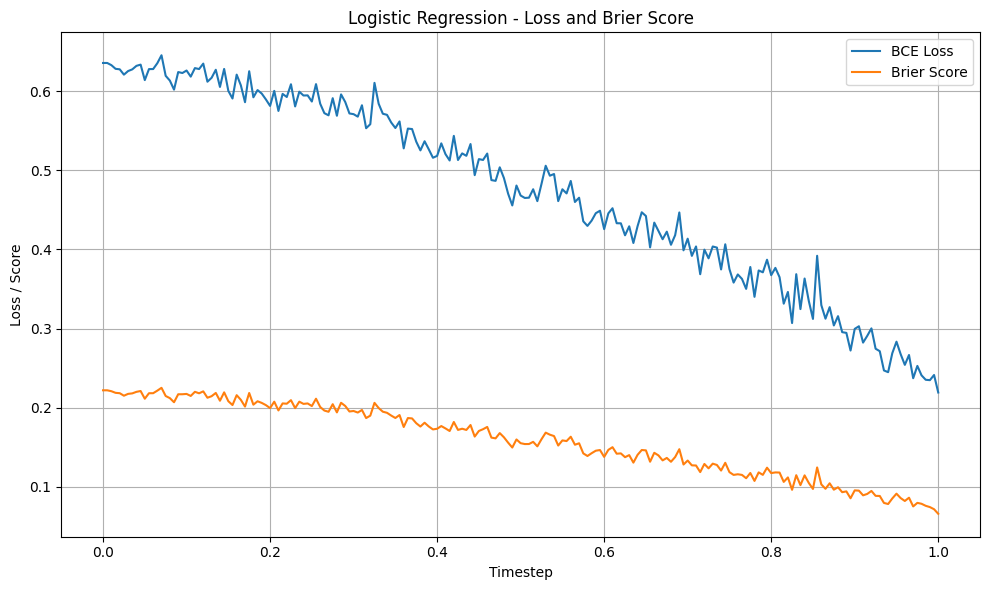

[0.6353983746544114, 0.6354158821758246, 0.6326468141026711, 0.6280219602170743, 0.6273986432493437, 0.6206649193529864, 0.6251972356567335, 0.6273267651838911, 0.6317683571406544, 0.6333192215927416, 0.6137944728866919, 0.6276608936176982, 0.6277289665864855, 0.635117530848768, 0.6451472366972877, 0.6191895640728893, 0.6131641947701311, 0.6017398202534565, 0.6239276332168702, 0.6227294483221717, 0.6258806371351967, 0.618163848832634, 0.6289359396580334, 0.6277356675818141, 0.6346093420976763, 0.611742414255498, 0.6167130680539012, 0.6268267766225996, 0.6051421077988919, 0.6278980650584663, 0.6002316888753023, 0.5905229272242083, 0.6206776457868405, 0.6072103040611018, 0.585859984923254, 0.6249547318583669, 0.5920631165478387, 0.6011785396881004, 0.596785003530102, 0.5893669740402956, 0.5811868871853854, 0.6001917982739954, 0.574825316657423, 0.5963527996082585, 0.5924453986969332, 0.6085375593160542, 0.5805205177220412, 0.5991511927849696, 0.5943201734056868, 0.5945027165577003, 0.586

In [15]:
# # Test accuracy of model for each timestep on test data and plot
# accuracies = []
# timesteps = []
import process_data
modules_to_reload = [
    'process_data',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

x = process_data.plot_loss(models, test_data, "Logistic Regression")
# process_data.plot_accuracy(models, test_data, "Logistic Regression")
# process_data.plot_loss(new_models, test_data, "Logistic Regression")

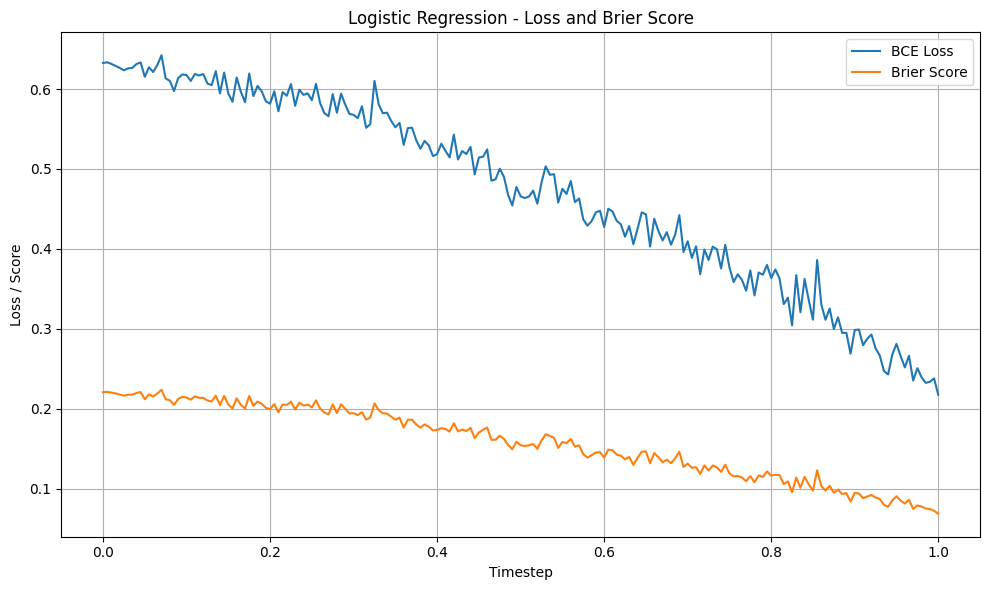

[0.6326421118478139, 0.6333801136750723, 0.6314370960141086, 0.6288991758067805, 0.6263535324997351, 0.6233867610468505, 0.6258373097585938, 0.6263493569103824, 0.6312128572839896, 0.6332598416624693, 0.6152878623308933, 0.6272554939264897, 0.6212204587310318, 0.6300719719490229, 0.6422247325843944, 0.613352085073756, 0.6101345484173153, 0.5974109783920276, 0.6138156198916416, 0.6182636442634314, 0.6175509441783114, 0.6101328543805741, 0.6188136400570052, 0.6168833546217245, 0.6187274112156772, 0.6069314845073475, 0.604858937497422, 0.622327826503604, 0.5944812859707274, 0.620574337664134, 0.5944223865999632, 0.5839994565885277, 0.6144244079149391, 0.5965404903788678, 0.5834883023776473, 0.6193243065576826, 0.5911269160854326, 0.6039067620965641, 0.5971099119808408, 0.5845954914336946, 0.5817025959715634, 0.5971670018935641, 0.5721649285035669, 0.5961546444132535, 0.5916033709158107, 0.6062360939233723, 0.5789861582439229, 0.599150081645711, 0.5926730942755141, 0.5945202139513004, 0.58

In [22]:
# # Test accuracy of model for each timestep on test data and plot
# accuracies = []
# timesteps = []
import process_data
modules_to_reload = [
    'process_data',
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

x = process_data.plot_loss(models, test_data, "Logistic Regression")
# process_data.plot_accuracy(models, test_data, "Logistic Regression")
# process_data.plot_loss(new_models, test_data, "Logistic Regression")

In [ ]:
model = models[0.99]
# features = ["relative_strength", "score_difference", "home_has_possession", "end.down", "end.distance", "end.yardsToEndzone",  "home_timeouts_left", "away_timeouts_left"]
data_point = [0.99, 0.5, -1, 1, 1, 1, 1, 1, 1]
model.predict_proba(np.array([data_point]))

In [156]:
# Save the model
import pickle
filename = 'logistic_regression_model.pickle'
pickle.dump(models, open(filename, 'wb'))

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
%reload_ext autoreload
from models.utils import SHAP_analysis
# model = models[0.99]
# # Health Check:
# if hasattr(model.model, "coef_"):
#     feature_names = model.all_features if hasattr(model, "all_features") else None
#     coefs = model.model.coef_[0]  # shape (n_features,)
#     if feature_names is not None and len(feature_names) == len(coefs):
#         for name, coef in zip(feature_names, coefs):
#             print(f"{name}: {coef}")

SHAP_analysis(models, training_data, test_data, "logistic_regression", "shap_values/LR_possession_probs_neg", timesteps_size=0.1, num_threads = 5)
# x = np.array([[0.1, 0.9, 20, 1, 0, 1, 50, 20, 2, 2, 2]])
# model.predict_proba(x)


Selected 11 timesteps on the grid before deduplication.
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Processing 11 timesteps (skipping 0 already done, 190 not selected).


ExactExplainer explainer:  22%|██▏       | 154/705 [00:00<?, ?it/s]





ExactExplainer explainer:  22%|██▏       | 157/705 [00:10<00:22, 24.78it/s]






ExactExplainer explainer:  23%|██▎       | 160/705 [00:10<00:31, 17.43it/s]





ExactExplainer explainer:  23%|██▎       | 162/705 [00:10<00:34, 15.91it/s]





ExactExplainer explainer:  24%|██▎       | 166/705 [00:10<00:26, 20.53it/s]







ExactExplainer explainer:  24%|██▍       | 169/705 [00:10<00:31, 16.78it/s]





ExactExplainer explainer:  24%|██▍       | 171/705 [00:11<00:31, 16.96it/s]






ExactExplainer explainer:  25%|██▍       | 174/705 [00:11<00:28, 18.34it/s]





ExactExplainer explainer:  25%|██▍       | 176/705 [00:11<00:30, 17.44it/s]





ExactExplainer explainer:  25%|██▌       | 178/705 [00:11<00:29, 17.75it/s]





ExactExplainer explainer:  26%|██▌       | 180/705 [00:11<00:29, 17.99it/s]




ExactExplainer explainer:  26%|██▌       | 182/705 [00:11<00:35, 14.91it/s]






ExactExplainer explainer:  26%|█

Saved logistic_regression_0.0.npz


ExactExplainer explainer:  30%|██▉       | 211/705 [00:13<00:30, 16.09it/s]




ExactExplainer explainer:  30%|███       | 213/705 [00:13<00:31, 15.41it/s]


ExactExplainer explainer:  30%|███       | 215/705 [00:13<00:35, 13.75it/s]




ExactExplainer explainer:  31%|███       | 217/705 [00:13<00:33, 14.60it/s]




ExactExplainer explainer:  31%|███       | 219/705 [00:13<00:32, 14.97it/s]




ExactExplainer explainer:  31%|███▏      | 222/705 [00:14<00:26, 17.92it/s]




ExactExplainer explainer:  32%|███▏      | 225/705 [00:14<00:24, 19.73it/s]




ExactExplainer explainer:  32%|███▏      | 228/705 [00:14<00:24, 19.68it/s]




ExactExplainer explainer:  33%|███▎      | 231/705 [00:14<00:31, 15.00it/s]




ExactExplainer explainer:  33%|███▎      | 233/705 [00:14<00:30, 15.39it/s]




ExactExplainer explainer:  33%|███▎      | 235/705 [00:14<00:29, 16.09it/s]




ExactExplainer explainer:  34%|███▍      | 238/705 [00:15<00:26, 17.36it/s]

ExactExplainer explainer:  34%|███▍      | 24

Saved logistic_regression_0.1.npz


...

Saved logistic_regression_0.9.npz






ExactExplainer explainer:  19%|█▉        | 227/1176 [00:10<00:25, 37.11it/s]

ExactExplainer explainer:  35%|███▌      | 417/1176 [00:16<00:25, 29.84it/s]

ExactExplainer explainer:  36%|███▌      | 424/1176 [00:16<00:30, 24.89it/s]

ExactExplainer explainer:  58%|█████▊    | 686/1176 [00:23<00:14, 33.53it/s]

ExactExplainer explainer:  60%|█████▉    | 705/1176 [00:24<00:12, 36.39it/s]

ExactExplainer explainer:  64%|██████▍   | 751/1176 [00:25<00:08, 47.25it/s]

ExactExplainer explainer:  66%|██████▌   | 771/1176 [00:26<00:11, 36.29it/s]

ExactExplainer explainer:  67%|██████▋   | 789/1176 [00:26<00:09, 39.26it/s]

ExactExplainer explainer:  71%|███████   | 837/1176 [00:27<00:08, 41.71it/s]

ExactExplainer explainer:  76%|███████▌  | 894/1176 [00:29<00:06, 42.30it/s]

ExactExplainer explainer:  83%|████████▎ | 977/1176 [00:31<00:05, 39.66it/s]

ExactExplainer explainer:  84%|████████▍ | 991/1176 [00:31<00:05, 36.41it/s]

ExactExplainer explainer:  91%|█████████▏| 1076/1176 [00:34<

Saved logistic_regression_1.0.npz
























































































ExactExplainer explainer: 3038it [02:02, 23.19it/s]                          

Saved logistic_regression_0.5.npz


In [23]:
from process_data import write_predictions
interpolated_dir = os.path.join(parent_dir, "dataset_interpolated_fixed")
write_predictions(models, interpolated_dir, [2024, 2025], 0, features, replace_nan_val = 0, phat_b = "LR_phat_b")

Loading data for 2025
Processed file:  game_401772888.csv
Processed file:  game_401772863.csv
Processed file:  game_401772877.csv
Processed file:  game_401772730.csv
Processed file:  game_401772724.csv
Processed file:  game_401772718.csv
Processed file:  game_401772917.csv
Processed file:  game_401772903.csv
Processed file:  game_401772902.csv
Processed file:  game_401772916.csv
Processed file:  game_401772719.csv
Processed file:  game_401772725.csv
Processed file:  game_401772731.csv
Processed file:  game_401772876.csv
Processed file:  game_401772862.csv
Processed file:  game_401772889.csv
Processed file:  game_401772848.csv
Processed file:  game_401772874.csv
Processed file:  game_401772860.csv
Processed file:  game_401772727.csv
Processed file:  game_401772733.csv
Processed file:  game_401772928.csv
Processed file:  game_401772900.csv
Processed file:  game_401772914.csv
Processed file:  game_401772915.csv
Processed file:  game_401772901.csv
Processed file:  game_401772929.csv
Proces

In [17]:
import os
import shutil

# Define the ancestor directory and the parent directory
src_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dest_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))

# Specify a list of directories to copy
sources = [
    os.path.join(src_dir, "dataset_interpolated_fixed", "2024"),
    os.path.join(src_dir, "dataset_interpolated_fixed", "2025")
]

destination = os.path.join(dest_dir, "test_final", "LR_model_ezS")

# Iterate through each source and copy
for source in sources:
    if os.path.exists(source):
        # Extract the year/folder name from source
        folder_name = os.path.basename(source)
        
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)
        print(f"Copied '{source}' to '{destination}'")
    else:
        print(f"Source '{source}' does not exist")

Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2024' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/LR_model_ezS'
Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2025' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_final/LR_model_ezS'
